--- INITIALIZING SUPER-FAST SIMULATION ---
Number of qubits: 12 (Search space: 4096)
Simulating for Oracle Accuracy A_Q = 1.0...
Simulating for Oracle Accuracy A_Q = 0.8...
Simulating for Oracle Accuracy A_Q = 0.55...

Simulation complete in 366.97 seconds!


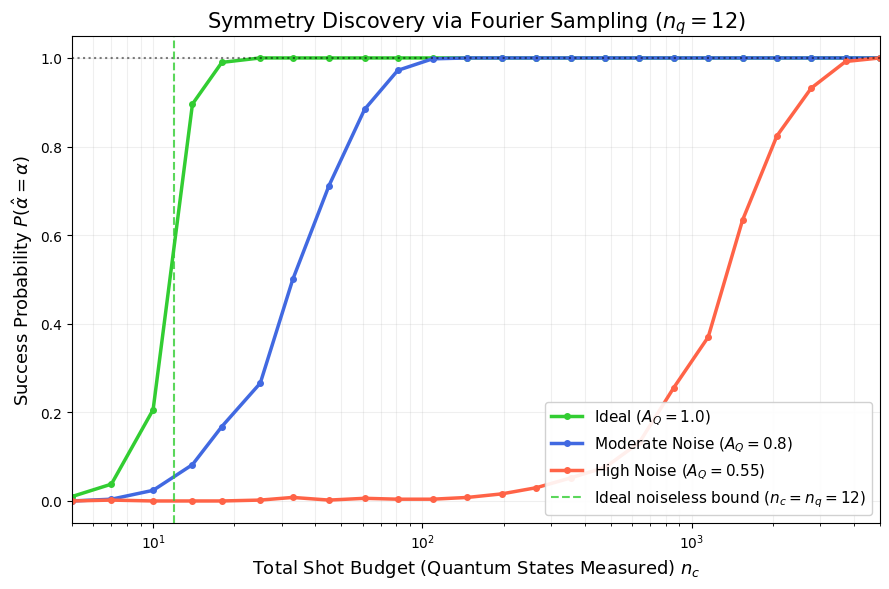

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import time

# ==========================================
# 1. SETUP & PRECOMPUTATION
# ==========================================
n_q = 12
N = 2**n_q
accuracies = [1.0, 0.8, 0.55]
repetitions = 500  # Reduced to 500 for a faster run, perfectly smooth enough

# Scan shot budgets (n_c)
n_c_values = np.unique(np.logspace(0, np.log10(5000), 30).astype(int))

print(f"--- INITIALIZING SUPER-FAST SIMULATION ---")
print(f"Number of qubits: {n_q} (Search space: {N})")

# [MASSIVE SPEEDUP 1]: Precompute all parities so we NEVER use string conversions
# PARITY_TABLE[x] stores the parity of the binary representation of x
PARITY_TABLE = np.array([bin(i).count('1') % 2 for i in range(N)], dtype=np.int8)

# ==========================================
# 2. FAST WALSH-HADAMARD TRANSFORM (FWHT)
# ==========================================
def fwht(a):
    """ Fast Walsh-Hadamard Transform (Classical Boolean Fourier Transform) """
    h = np.copy(a)
    n = len(h)
    step = 1
    while step < n:
        for i in range(0, n, step * 2):
            for j in range(step):
                x, y = h[i + j], h[i + j + step]
                h[i + j] = x + y
                h[i + j + step] = x - y
        step *= 2
    return h

# ==========================================
# 3. HYPER-FAST FOURIER SAMPLING & FWHT SOLVER
# ==========================================
def fast_fourier_sampling(hidden_alpha, n_q, n_c, A_Q):
    # 1. Quantum Hardware spits out random measurement strings z
    z_measurements = np.random.randint(0, N, size=n_c)
    
    # 2. Fast Parity Lookup (No strings!)
    true_parities = PARITY_TABLE[z_measurements & hidden_alpha]
    
    # 3. Apply Hardware Noise A_Q
    noise_mask = np.random.rand(n_c) > A_Q
    measured_parities = true_parities ^ noise_mask
    
    # 4. CLASSICAL FWHT SOLVER (The Magic)
    # Instead of guessing alphas, we build a landscape: +1 for even parity, -1 for odd
    signs = 1 - 2 * measured_parities 
    
    # Create an empty landscape and add up the "votes" for each z we measured
    P = np.zeros(N)
    np.add.at(P, z_measurements, signs) 
    
    # The FWHT instantly computes the correlation of P against ALL 4,096 possible alphas
    spectrum = fwht(P)
    
    # The candidate with the highest Fourier peak is our decoded symmetry!
    best_alpha = np.argmax(spectrum)
            
    return best_alpha == hidden_alpha



In [ ]:
# ==========================================
# 4. RUN NUMERICAL EXPERIMENTS
# ==========================================
results = {A_Q: [] for A_Q in accuracies}

start_time = time.time()

for A_Q in accuracies:
    print(f"Simulating for Oracle Accuracy A_Q = {A_Q}...")
    for n_c in n_c_values:
        successful_trials = 0
        for _ in range(repetitions):
            hidden_alpha = np.random.randint(1, N)
            if fast_fourier_sampling(hidden_alpha, n_q, n_c, A_Q):
                successful_trials += 1
        results[A_Q].append(successful_trials / repetitions)

print(f"\nSimulation complete in {time.time() - start_time:.2f} seconds!")


Simulating for Oracle Accuracy A_Q = 1.0...
Simulating for Oracle Accuracy A_Q = 0.8...
Simulating for Oracle Accuracy A_Q = 0.55...

Simulation complete in 383.65 seconds!


ValueError: 
Ideal ($A_ho = 1.0$)
       ^
ParseException: Expected end of text, found '$'  (at char 7), (line:1, col:8)

Error in callback <function _draw_all_if_interactive at 0x116d2db80> (for post_execute):


ValueError: 
Ideal ($A_ho = 1.0$)
       ^
ParseException: Expected end of text, found '$'  (at char 7), (line:1, col:8)

ValueError: 
Ideal ($A_ho = 1.0$)
       ^
ParseException: Expected end of text, found '$'  (at char 7), (line:1, col:8)

<Figure size 900x600 with 1 Axes>

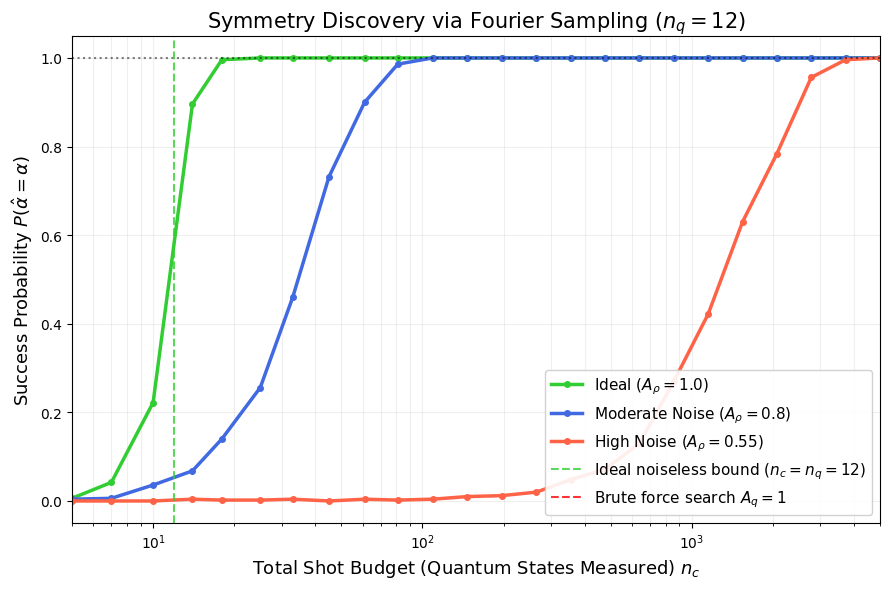

In [6]:

# ==========================================
# 5. VISUALIZATION (Publication Ready)
# ==========================================
plt.figure(figsize=(9, 6))

colors = ['limegreen', 'royalblue', 'tomato']
labels = [r'Ideal ($A_\rho = 1.0$)', r'Moderate Noise ($A_\rho = 0.8$)', r'High Noise ($A_\rho = 0.55$)']

for A_Q, color, label in zip(accuracies, colors, labels):
    plt.plot(n_c_values, results[A_Q], marker='o', markersize=4, 
             linewidth=2.5, color=color, label=label)

plt.xscale('log') 
plt.xlim(5, 5000)
plt.ylim(-0.05, 1.05)
plt.axhline(y=1.0, color='black', linestyle=':', alpha=0.5)

plt.axvline(x=n_q, color='limegreen', linestyle='--', alpha=0.8, 
            label=f'Ideal noiseless bound ($n_c = n_q = {n_q}$)')

plt.xlabel(r'Total Shot Budget (Quantum States Measured) $n_c$', fontsize=13)
plt.ylabel(r'Success Probability $P(\hat{\alpha} = \alpha)$', fontsize=13)
plt.title(f'Symmetry Discovery via Fourier Sampling ($n_q = {n_q}$)', fontsize=15)
plt.axvline(x=2**n_q*n_q, color='red', linestyle='--', alpha=0.8, 
            label=f'Brute force search $A_q=1$')

plt.legend(loc='lower right', fontsize=11, framealpha=0.9)
plt.grid(True, which="both", ls="-", alpha=0.2)

plt.tight_layout()
plt.show()

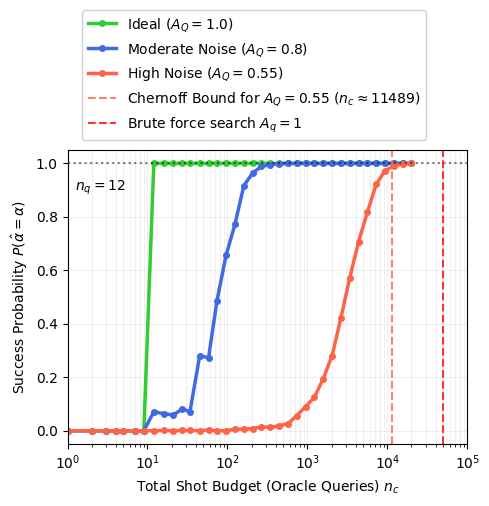

In [ ]:
# ==========================================
# 5. VISUALIZATION (Publication Ready)
# ==========================================
plt.figure(figsize=(5, 6))

colors = ['limegreen', 'royalblue', 'tomato']
labels = ['Ideal ($A_Q = 1.0$)', 'Moderate Noise ($A_Q = 0.8$)', 'High Noise ($A_Q = 0.55$)']

for A_Q, color, label in zip(accuracies, colors, labels):
    plt.plot(n_c_values, results[A_Q], marker='o', markersize=4, 
             linewidth=2.5, color=color, label=label)

# Theoretical marker for A_Q = 0.55
plt.axvline(x=nc_predicted_055, color='tomato', linestyle='--', alpha=0.8, 
            label=f'Chernoff Bound for $A_Q=0.55$ ($n_c \\approx {nc_predicted_055}$)')

# Formatting for PRX style
plt.xscale('log') 
plt.xlim(1, 100000)
plt.ylim(-0.05, 1.05)
plt.axhline(y=1.0, color='black', linestyle=':', alpha=0.5)

plt.xlabel(r'Total Shot Budget (Oracle Queries) $n_c$')
plt.ylabel(r'Success Probability $P(\hat{\alpha} = \alpha)$')


plt.legend(loc='upper left', framealpha=0.9, ncol=1, bbox_to_anchor=(0.02, 1.5) )
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.text(1.25,0.9, r'$n_q =12$')

plt.tight_layout()
plt.show()